In [25]:
from helpers.plotting_functions import plot_3d_gp, plot_3d_data, plot_single_input_gp_posterior
from helpers.util_functions import prior_distribution, reparameterize_model_full, reparameterize_model_trainable, log_normalized_prior, extract_trainable_model_parameters
from laplace_model_selection.metrics import Lap0, LapAIC, LapBIC, AIC, BIC, NestedSampling, MLL, MAP
from helpers.training_functions import granso_optimization
import matplotlib.pyplot as plt
import pandas as pd
import itertools
import torch
import gpytorch
torch.set_default_dtype(torch.float64)

import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import dill
import copy

In [26]:
X = torch.linspace(0, 10, 100)
y = torch.linspace(0, 10, 100)


base_kernel_parameter_priors = {
    ("RBFKernel", "lengthscale"): {"mean": 0.0, "std": 10.0}, 
    ("MaternKernel", "lengthscale"): {"mean": 0.0, "std": 10.0},
    ("LinearKernel", "variance"): {"mean": 0.0, "std": 10.0},
    ("AffineKernel", "variance"): {"mean": 0.0, "std": 10.0},
    ("RQKernel", "lengthscale"): {"mean": 0.0, "std": 10.0},
    ("RQKernel", "alpha"): {"mean": 0.0, "std": 10.0},
    ("CosineKernel", "period_length"): {"mean": 0.0, "std": 10.0},
    ("PeriodicKernel", "lengthscale"): {"mean": 0.0, "std": 10.0},
    ("PeriodicKernel", "period_length"): {"mean": 0.0, "std": 10.0},
    ("ScaleKernel", "outputscale"): {"mean": 0.0, "std": 10.0},
    ("NSumCSEKernel", "n_sum_scale"): {"mean": 0.0, "std": 10.0},
    ("LODE_Kernel", "signal_variance_2_0"): {"mean": 0.0, "std": 10.0},  # full match
    ("LODE_Kernel", "lengthscale"): {"mean": 0.0, "std": 10.0},           # base fallback
}


base_parameter_priors = {
    "likelihood.raw_task_noises": {"mean": 0.0, "std": 10.0},
    "likelihood.raw_noise": {"mean": 0.0, "std": 10.0}
}


base_kernel_param_specs = {
    ("RBFKernel", "lengthscale"): {"bounds": (-1.0, 10.0), "type":"uniform"}, # add ', "type": "uniform"},' # to use uniform distribution
    ("MaternKernel", "lengthscale"): {"bounds": (-1.0, 10.0), "type":"uniform"},
    ("LinearKernel", "variance"): {"bounds": (1e-1, 1.0)},
    ("AffineKernel", "variance"): {"bounds": (1e-1, 1.0)},
    ("RQKernel", "lengthscale"): {"bounds": (-1.0, 10.0), "type":"uniform"},
    ("RQKernel", "alpha"): {"bounds": (1e-1, 10.0), "type":"uniform"},
    ("CosineKernel", "period_length"): {"bounds": (-1.0, 10.0), "type": "uniform"},
    #("PeriodicKernel", "lengthscale"): {"bounds": (1e-1, 5.0)},
    #("PeriodicKernel", "period_length"): {"bounds": (-1.0, 10.0), "type": "uniform"},
    ("PeriodicKernel", "period_length"): {"bounds": (-1.0, 10.0), "type": "uniform"},
    ("ScaleKernel", "outputscale"): {"bounds": (-1.0, 10.0), "type": "uniform"},
    ("NSumCSEKernel", "n_sum_scale"): {"bounds": (-1.0, 10.0), "type": "uniform"},
    #("LODE_Kernel", "signal_variance_2_0"): {"bounds": (0.05, 0.5)},  # full match
    ("LODE_Kernel", "signal_variance"): {"bounds": (1e-1, 10)},  # base
    ("LODE_Kernel", "lengthscale"): {"bounds": (1e-1, 5.0)},           
}


base_param_specs = {
    "likelihood.raw_task_noises": {"bounds": (1e-1, 1e-0)},
    "likelihood.raw_noise": {"bounds": (1e-0, 1e+1), "type":"uniform"}
}

In [27]:
import os
#results_file_to_load = f"minimal_laplace_inconsistency_prod_manual.pkl"
results_file_to_load = f"minimal_laplace_inconsistency_sum_manual_noise_free.pkl"
ALL_METRIC_LOGS = dill.load(open(os.path.join("./", results_file_to_load), "rb"))

In [28]:
model_num = 15 
print(ALL_METRIC_LOGS[model_num].keys())
#print(ALL_METRIC_LOGS[model_num]["log ML"])
import pprint
#pprint.pprint(ALL_METRIC_LOGS[model_num]["log MAP"]["state_dict"])
#torch.linalg.eig(ALL_METRIC_LOGS[model_num]["Lap0"]["logs"]["Hessian pre correction"])
NS_log = dill.load(open(ALL_METRIC_LOGS[model_num]["NestedSampling"]["logs"]['res file'], "rb"))

dict_keys(['log MAP', 'log ML', 'Lap0', 'LapAIC', 'LapBIC', 'AIC', 'BIC', 'NestedSampling'])


In [33]:
for key in ALL_METRIC_LOGS:
    print(key)
    for metric_AML in ALL_METRIC_LOGS[key]:
        if metric_AML == "Lap0":
            print(f"Lap: {ALL_METRIC_LOGS[key][metric_AML]["logs"]['laplace without replacement']}")
        print(f"{metric_AML}: {ALL_METRIC_LOGS[key][metric_AML]["model_evidence_approx"]}")

1
log MAP: -110.33385214517052
log ML: -106.26495891751951
Lap: -108.05594588188602
Lap0: -110.33385214517052
LapAIC: -111.33385214517052
LapBIC: -112.63643723816458
AIC: 214.52991783503902
BIC: 217.13508802102712
NestedSampling: -108.0797315595863
2
log MAP: -113.16586901416377
log ML: -106.26495891751888
Lap: -107.91165367242012
Lap0: -113.16586901416372
LapAIC: -115.16586901416372
LapBIC: -117.7710392001518
AIC: 216.52991783503776
BIC: 221.74025820701394
NestedSampling: -107.467630612609
3
log MAP: -116.24508102384279
log ML: -106.26495891751887
Lap: -107.83280228794365
Lap0: -116.24508102384277
LapAIC: -119.24508102384277
LapBIC: -123.15283630282491
AIC: 218.52991783503768
BIC: 226.34542839300195
NestedSampling: -107.20177863554572
4
log MAP: -119.38931937737634
log ML: -106.26495891751892
Lap: -107.73529782708488
Lap0: -119.38931937737634
LapAIC: -123.38931937737634
LapBIC: -128.59965974935253
AIC: 220.5299178350378
BIC: 230.95059857899017
NestedSampling: -107.09840357973073
5
log

In [40]:
for key in ALL_METRIC_LOGS:
    print(ALL_METRIC_LOGS[model_num]["log MAP"]["logs"])
    print(f"{ALL_METRIC_LOGS[model_num]["log MAP"]["logs"]["data fit"]} {ALL_METRIC_LOGS[model_num]["log MAP"]["logs"]["complexity term"]} ={ALL_METRIC_LOGS[model_num]["log MAP"]["logs"]["data fit"] + ALL_METRIC_LOGS[model_num]["log MAP"]["logs"]["complexity term"]} ")
    print(f"{ALL_METRIC_LOGS[model_num]["log ML"]["logs"]["data fit"]} {ALL_METRIC_LOGS[model_num]["log ML"]["logs"]["complexity term"]} ={ALL_METRIC_LOGS[model_num]["log ML"]["logs"]["data fit"] + ALL_METRIC_LOGS[model_num]["log ML"]["logs"]["complexity term"]} ")
    print("===")

{'scaling': False, 'logarithmic': True, 'prior_value': tensor(-48.3386), 'data fit': tensor(-6.4962), 'complexity term': tensor(-7.8757), 'normalization constant': -91.89385332046727}
-6.496174806308981 -7.875713493900916 =-14.371888300209896 
-6.399828036306422 -7.971277560745191 =-14.371105597051614 
===
{'scaling': False, 'logarithmic': True, 'prior_value': tensor(-48.3386), 'data fit': tensor(-6.4962), 'complexity term': tensor(-7.8757), 'normalization constant': -91.89385332046727}
-6.496174806308981 -7.875713493900916 =-14.371888300209896 
-6.399828036306422 -7.971277560745191 =-14.371105597051614 
===
{'scaling': False, 'logarithmic': True, 'prior_value': tensor(-48.3386), 'data fit': tensor(-6.4962), 'complexity term': tensor(-7.8757), 'normalization constant': -91.89385332046727}
-6.496174806308981 -7.875713493900916 =-14.371888300209896 
-6.399828036306422 -7.971277560745191 =-14.371105597051614 
===
{'scaling': False, 'logarithmic': True, 'prior_value': tensor(-48.3386), 'da

In [ ]:
sfpl = torch.nn.Softplus()
training_method = "log MAP"
for key in ALL_METRIC_LOGS:
    print(f"{[sfpl(ALL_METRIC_LOGS[key][training_method]["state_dict"][param]) for param in ALL_METRIC_LOGS[key][training_method]["state_dict"] if ("covar_module.raw_n_" in param and not "constraint" in param) ]}")
    print(f"Prod: {torch.prod(torch.tensor([sfpl(ALL_METRIC_LOGS[key][training_method]["state_dict"][param]) for param in ALL_METRIC_LOGS[key][training_method]["state_dict"] if ("covar_module.raw_n_" in param and not "constraint" in param)]))}")
    print(f"Sum: {torch.sum(torch.tensor([sfpl(ALL_METRIC_LOGS[key][training_method]["state_dict"][param]) for param in ALL_METRIC_LOGS[key][training_method]["state_dict"] if ("covar_module.raw_n_" in param and not "constraint" in param)]))}")
    print("===")

[tensor(12.4015)]
Prod: 12.401495635237257
Sum: 12.401495635237257
===
[tensor(6.4499), tensor(6.3617)]
Prod: 41.032308248288295
Sum: 12.811597243650052
===
[tensor(4.5452), tensor(4.4037), tensor(4.4037)]
Prod: 88.14332140906889
Sum: 13.352610772456064
===
[tensor(3.5265), tensor(3.3639), tensor(3.3639), tensor(3.3639)]
Prod: 134.23541875586162
Sum: 13.618152055428208
===
[tensor(2.8889), tensor(2.7200), tensor(2.7200), tensor(2.7200), tensor(2.7200)]
Prod: 158.1240348690276
Sum: 13.768837265771399
===
[tensor(2.4707), tensor(2.2705), tensor(2.2705), tensor(2.2705), tensor(2.2705), tensor(2.2705)]
Prod: 149.07919829967489
Sum: 13.823143749717664
===
[tensor(2.1271), tensor(1.9602), tensor(1.9602), tensor(1.9602), tensor(1.9602), tensor(1.9602), tensor(1.9602)]
Prod: 120.64881300789861
Sum: 13.887994670965384
===
[tensor(1.8997), tensor(1.7206), tensor(1.7206), tensor(1.7206), tensor(1.7206), tensor(1.7206), tensor(1.7206), tensor(1.7206)]
Prod: 84.82427686906777
Sum: 13.94420204226579

In [31]:
training_method = "log ML"
for key in ALL_METRIC_LOGS:
    print(ALL_METRIC_LOGS[key][training_method]["train_log"].hessians[0])

KeyError: 'train_log'

In [ ]:
sfpl = torch.nn.Softplus()
for key in ALL_METRIC_LOGS:
    print(f"{ALL_METRIC_LOGS[key]["Lap0"]["logs"]["Hessian pre correction"]}")
    print("===")

tensor([[0.0660]])
===
tensor([[0.0594, 0.0495],
        [0.0495, 0.0594]])
===
tensor([[0.0513, 0.0416, 0.0416],
        [0.0416, 0.0511, 0.0416],
        [0.0416, 0.0416, 0.0511]])
===
tensor([[0.0464, 0.0371, 0.0371, 0.0371],
        [0.0371, 0.0459, 0.0369, 0.0369],
        [0.0371, 0.0369, 0.0459, 0.0369],
        [0.0371, 0.0369, 0.0369, 0.0459]])
===
tensor([[0.0426, 0.0335, 0.0335, 0.0335, 0.0335],
        [0.0335, 0.0417, 0.0331, 0.0331, 0.0331],
        [0.0335, 0.0331, 0.0417, 0.0331, 0.0331],
        [0.0335, 0.0331, 0.0331, 0.0417, 0.0331],
        [0.0335, 0.0331, 0.0331, 0.0331, 0.0417]])
===
tensor([[0.0397, 0.0307, 0.0307, 0.0307, 0.0307, 0.0307],
        [0.0307, 0.0381, 0.0300, 0.0300, 0.0300, 0.0300],
        [0.0307, 0.0300, 0.0381, 0.0300, 0.0300, 0.0300],
        [0.0307, 0.0300, 0.0300, 0.0381, 0.0300, 0.0300],
        [0.0307, 0.0300, 0.0300, 0.0300, 0.0381, 0.0300],
        [0.0307, 0.0300, 0.0300, 0.0300, 0.0300, 0.0381]])
===
tensor([[0.0366, 0.0278, 0.0278,

In [ ]:
ALL_METRIC_LOGS[2]

{'log MAP': {'name': 'log MAP',
  'state_dict': OrderedDict([('likelihood.noise_covar.raw_noise',
                tensor([0.])),
               ('likelihood.noise_covar.raw_noise_constraint.lower_bound',
                tensor(0.0001)),
               ('likelihood.noise_covar.raw_noise_constraint.upper_bound',
                tensor(inf)),
               ('covar_module.raw_n_sum_scale_0', tensor(6.4483)),
               ('covar_module.raw_n_sum_scale_1', tensor(6.3599)),
               ('covar_module.base_kernel.raw_lengthscale',
                tensor([[0.5413]])),
               ('covar_module.base_kernel.raw_lengthscale_constraint.lower_bound',
                tensor(0.)),
               ('covar_module.base_kernel.raw_lengthscale_constraint.upper_bound',
                tensor(inf)),
               ('covar_module.raw_n_sum_scale_0_constraint.lower_bound',
                tensor(0.)),
               ('covar_module.raw_n_sum_scale_0_constraint.upper_bound',
                tensor(inf)

[tensor([1.]), tensor([-0.7072, -0.7070]), tensor([-0.5782, -0.5769, -0.5769]), tensor([-0.5024, -0.4992, -0.4992, -0.4992]), tensor([-0.4516, -0.4461, -0.4461, -0.4461, -0.4461]), tensor([-0.4159, -0.4067, -0.4067, -0.4067, -0.4067, -0.4067]), tensor([-0.3866, -0.3765, -0.3765, -0.3765, -0.3765, -0.3765, -0.3765]), tensor([-0.3650, -0.3519, -0.3519, -0.3519, -0.3519, -0.3519, -0.3519, -0.3519]), tensor([-0.3513, -0.3310, -0.3310, -0.3310, -0.3310, -0.3310, -0.3310, -0.3310,
        -0.3310]), tensor([-0.3224, -0.3155, -0.3155, -0.3155, -0.3155, -0.3155, -0.3155, -0.3155,
        -0.3155, -0.3155]), tensor([-0.3096, -0.3007, -0.3007, -0.3007, -0.3007, -0.3007, -0.3007, -0.3007,
        -0.3007, -0.3007, -0.3007]), tensor([-0.2976, -0.2878, -0.2878, -0.2878, -0.2878, -0.2878, -0.2878, -0.2878,
        -0.2878, -0.2878, -0.2878, -0.2878]), tensor([-0.2964, -0.2757, -0.2757, -0.2757, -0.2757, -0.2757, -0.2757, -0.2757,
        -0.2757, -0.2757, -0.2757, -0.2757, -0.2757]), tensor([-0.2859

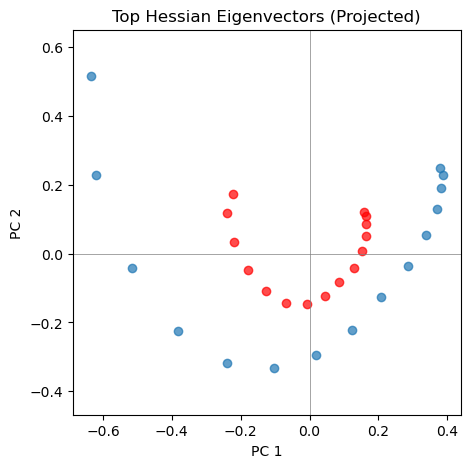

In [ ]:
def pad_to_N(v, N):
    v = v.reshape(-1)
    z = torch.zeros(N, dtype=v.dtype, device=v.device)
    z[: v.numel()] = v
    return z

def make_comparable_evecs(evec_list, eps=1e-12):
    """
    evec_list: list of tensors, each shape (k,) or (k,1), varying k
    Returns X: (M, N) matrix of comparable, normalized, sign-aligned vectors
    """
    N = max(v.numel() for v in evec_list)
    X = torch.stack([pad_to_N(v, N) for v in evec_list], dim=0)  # (M, N)

    # normalize
    X = X / (torch.linalg.norm(X, dim=1, keepdim=True).clamp_min(eps))

    # sign-fix: align each vector to the mean direction
    ref = X.mean(dim=0)
    ref = ref / torch.linalg.norm(ref).clamp_min(eps)
    signs = torch.sign(X @ ref)  # (M,)
    signs[signs == 0] = 1
    X = X * signs[:, None]

    return X

def make_scaled_evecs(evec_list, eval_list, eps=1e-12):
    N = max(v.numel() for v in evec_list)

    X = []
    for v, lam in zip(evec_list, eval_list):
        z = torch.zeros(N)
        z[:v.numel()] = v.squeeze()
        z = z * torch.sqrt(lam)
        X.append(z)

    X = torch.stack(X)

    # sign fix (still important!)
    ref = X.mean(dim=0)
    ref = ref / torch.linalg.norm(ref).clamp_min(eps)
    signs = torch.sign(X @ ref)
    signs[signs == 0] = 1
    X = X * signs[:, None]

    return X

def pca_project_2d(X):
    """
    X: (M, N) comparable vectors
    Returns Y: (M, 2) and U: (N, 2) orthonormal basis
    """
    Xc = X - X.mean(dim=0, keepdim=True)
    # SVD: Xc = U_svd S V^T, principal directions are columns of V
    _, _, Vt = torch.linalg.svd(Xc, full_matrices=False)
    U = Vt[:2].T  # (N, 2)
    Y = Xc @ U    # (M, 2)
    return Y, U


eigenvector_list = list()
eigenvalue_list = list()


for i, A in enumerate([ALL_METRIC_LOGS[k]["Lap0"]["logs"]["Hessian pre correction"] for k in ALL_METRIC_LOGS]):
    eigvals, eigvecs = torch.linalg.eigh(A.detach())
    #if "prod" in results_file_to_load and i == 1:
    #    eigvecs = -eigvecs
    idx = torch.argsort(eigvals, descending=True)
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:,idx]

    eigenvector_list.append(eigvecs[:, 0])# * torch.sqrt(eigvals[0]))
    eigenvalue_list.append(eigvals[0])

print(eigenvector_list)
Y_deg, U_deg = pca_project_2d(make_comparable_evecs(eigenvector_list))
Y_mag, U_mag = pca_project_2d(make_scaled_evecs(eigenvector_list, eigenvalue_list))
print(Y_deg)
print(Y_mag)
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.scatter(Y_deg[:, 0], Y_deg[:, 1], alpha=0.7)
plt.scatter(Y_mag[:, 0], Y_mag[:, 1], alpha=0.7, color="red")
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("Top Hessian Eigenvectors (Projected)")
plt.axis("equal")
plt.show()

In [ ]:
eigenvector_list

[tensor([1.]),
 tensor([-0.7072, -0.7070]),
 tensor([-0.5782, -0.5769, -0.5769]),
 tensor([-0.5024, -0.4992, -0.4992, -0.4992]),
 tensor([-0.4516, -0.4461, -0.4461, -0.4461, -0.4461]),
 tensor([-0.4159, -0.4067, -0.4067, -0.4067, -0.4067, -0.4067]),
 tensor([-0.3866, -0.3765, -0.3765, -0.3765, -0.3765, -0.3765, -0.3765]),
 tensor([-0.3650, -0.3519, -0.3519, -0.3519, -0.3519, -0.3519, -0.3519, -0.3519]),
 tensor([-0.3513, -0.3310, -0.3310, -0.3310, -0.3310, -0.3310, -0.3310, -0.3310,
         -0.3310]),
 tensor([-0.3224, -0.3155, -0.3155, -0.3155, -0.3155, -0.3155, -0.3155, -0.3155,
         -0.3155, -0.3155]),
 tensor([-0.3096, -0.3007, -0.3007, -0.3007, -0.3007, -0.3007, -0.3007, -0.3007,
         -0.3007, -0.3007, -0.3007]),
 tensor([-0.2976, -0.2878, -0.2878, -0.2878, -0.2878, -0.2878, -0.2878, -0.2878,
         -0.2878, -0.2878, -0.2878, -0.2878]),
 tensor([-0.2964, -0.2757, -0.2757, -0.2757, -0.2757, -0.2757, -0.2757, -0.2757,
         -0.2757, -0.2757, -0.2757, -0.2757, -0.2757])

tensor([0.1344+0.j, 0.0096+0.j, 0.0095+0.j])


/home/andreas/anaconda3/envs/laplace/lib/python3.12/site-packages/mpl_toolkits/mplot3d/axes3d.py:3305: ComplexWarning: Casting complex values to real discards the imaginary part
  UVW = np.column_stack(input_args[3:]).astype(float)


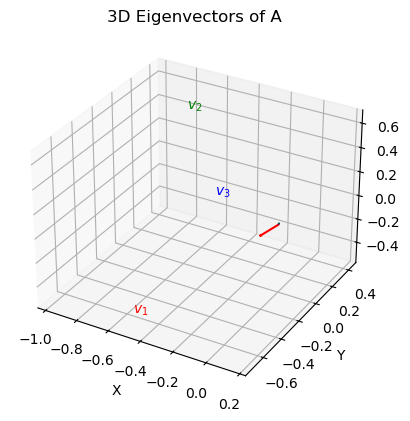

In [ ]:
A = ALL_METRIC_LOGS[3]["Lap0"]["logs"]["Hessian pre correction"]
# Compute eigenvalues and eigenvectors
eigvals, eigvecs = torch.linalg.eig(A)   # eigvecs: columns are eigenvectors
print(eigvals)

# For real matrices, eigenvectors *may* be complex; take the real part
eigvecs = eigvecs.real

# Convert to numpy for plotting
eigvecs_np = eigvecs.detach().numpy()  # shape (3, 3), columns are eigenvectors

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# Convert to numpy for plotting
eigvals_np = eigvals.detach().numpy()        # shape (3,)
eigvecs_np = eigvecs.detach().numpy()        # shape (3, 3), columns = eigenvectors

# Plot each eigenvector as an arrow from the origin
colors = ['r', 'g', 'b']
scaled_vecs = []

for i in range(3):
    v = eigvecs_np[:, i]        # eigenvector
    lam = eigvals_np[i]         # corresponding eigenvalue
    v_scaled = v * lam          # scale vector by eigenvalue → controls arrow length
    scaled_vecs.append(v_scaled)

    ax.quiver(
        0, 0, 0,
        v_scaled[0], v_scaled[1], v_scaled[2],
        color=colors[i],
        arrow_length_ratio=0.1
    )
    ax.text(v[0], v[1], v[2], f"$v_{i+1}$", color=colors[i])

# Make axes equal-ish
all_points = np.column_stack([np.zeros(3), eigvecs_np])  # origin + eigenvectors
x_limits = (all_points[0].min(), all_points[0].max())
y_limits = (all_points[1].min(), all_points[1].max())
z_limits = (all_points[2].min(), all_points[2].max())

max_range = max(
    x_limits[1] - x_limits[0],
    y_limits[1] - y_limits[0],
    z_limits[1] - z_limits[0],
) / 2.0

mid_x = (x_limits[0] + x_limits[1]) / 2.0
mid_y = (y_limits[0] + y_limits[1]) / 2.0
mid_z = (z_limits[0] + z_limits[1]) / 2.0

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Eigenvectors of A')

plt.show()

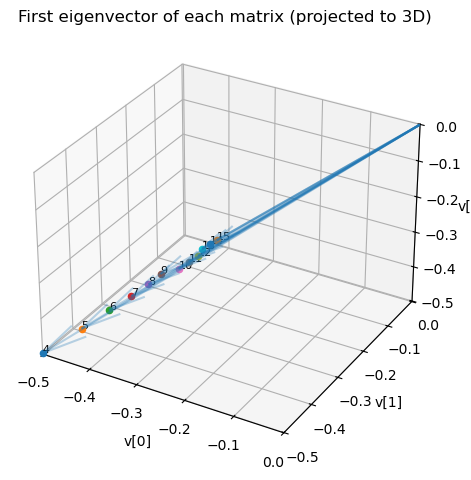

In [ ]:
vecs_3d = []

for A in [ALL_METRIC_LOGS[k]["Lap0"]["logs"]["Hessian pre correction"] for k in ALL_METRIC_LOGS]:
    if A.shape[0] < 4: 
        continue
    eigvals, eigvecs = torch.linalg.eig(A)  # eigvecs: columns are eigenvectors

    # First eigenvector (column 0)
    v = eigvecs[:, 0]

    # Use real part (common if A is real; adjust if you want magnitude etc.)
    v = v.real

    # Take the first three entries for 3D projection
    if v.numel() < 3:
        # Skip if matrix is too small (or handle differently if you like)
        continue
    v3 = v[:3]

    vecs_3d.append(v3.detach().numpy())

vecs_3d = np.stack(vecs_3d, axis=0)  # shape: (num_mats, 3)

# -------------------------------------------------------
# Plot in 3D
# -------------------------------------------------------
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot arrows and points
for i, v in enumerate(vecs_3d):
    ax.quiver(
        0, 0, 0,        # origin
        v[0], v[1], v[2],
        arrow_length_ratio=0.1,
        alpha=0.3
    )
    ax.scatter(v[0], v[1], v[2])
    ax.text(v[0], v[1], v[2], f"{i+4}", fontsize=8)

# Make axes roughly equal
all_points = np.vstack([np.zeros((1, 3)), vecs_3d])
mins = all_points.min(axis=0)
maxs = all_points.max(axis=0)
centers = (mins + maxs) / 2.0
max_range = (maxs - mins).max() / 2.0

ax.set_xlim(centers[0] - max_range, centers[0] + max_range)
ax.set_ylim(centers[1] - max_range, centers[1] + max_range)
ax.set_zlim(centers[2] - max_range, centers[2] + max_range)

ax.set_xlabel("v[0]")
ax.set_ylabel("v[1]")
ax.set_zlabel("v[2]")
ax.set_title("First eigenvector of each matrix (projected to 3D)")

plt.tight_layout()
plt.show()

[0.10895519936639926, 0.1343547907117801, 0.1568971447960639, 0.1748369910322506, 0.18966266872012452, 0.1988374779065508, 0.20430684701498653, 0.20521366092343546, 0.21481034024585177, 0.2111971513444846, 0.20697709090438712, 0.2021010355827299, 0.20082645904667204, 0.19759667886227744]
[[ 0.07705223  0.07703369]
 [-0.07768007 -0.07751457]
 [-0.07881978 -0.07832445]
 [-0.07895034 -0.0779981 ]
 [-0.07888354 -0.07713536]
 [-0.0768681  -0.07486392]
 [-0.07458156 -0.07189166]
 [-0.07209199 -0.06792955]
 [-0.06926109 -0.06777937]
 [-0.06538116 -0.06350554]
 [-0.06160037 -0.05957799]
 [-0.05990244 -0.05571993]
 [-0.05742576 -0.05337353]
 [-0.05457757 -0.05075553]]


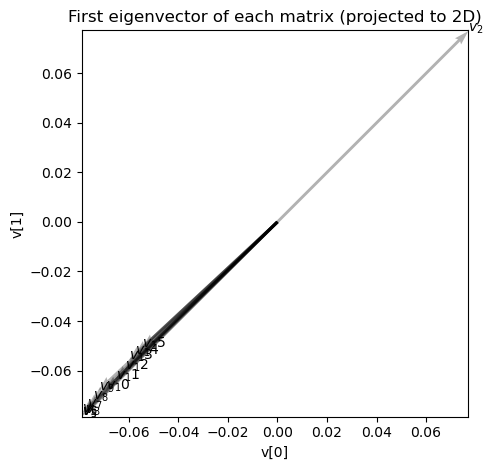

In [ ]:
vecs_2d = []
vals_2d = []

for A in [ALL_METRIC_LOGS[k]["Lap0"]["logs"]["Hessian pre correction"] for k in ALL_METRIC_LOGS]:
    eigvals, eigvecs = np.linalg.eig(A.detach().numpy())
    idx = eigvals.argsort()[::-1]   
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:,idx]

    v = eigvecs[:, 0].real  # first eigenvector, real part

    if len(v) < 2:
        continue

    v2 = v[:2]
    vecs_2d.append(v2)
    vals_2d.append(eigvals[0].real)

vecs_2d = np.stack(vecs_2d, axis=0)  # shape: (num_mats, 2)
print(vals_2d)
# -------------------------------------------------------
# 2D plot
# -------------------------------------------------------
fig, ax = plt.subplots()

scaled_vecs = []
for i, v in enumerate(vecs_2d):
    lam = vals_2d[i]         # corresponding eigenvalue
    v_scaled = v * lam          # scale vector by eigenvalue → controls arrow length
    scaled_vecs.append(v_scaled)

    ax.quiver(
        0, 0,
        v_scaled[0], v_scaled[1],
        alpha=0.3,
        angles='xy', scale_units='xy', scale=1,
    )
    #ax.scatter(v[0], v[1], alpha=1.0)
    ax.text(v_scaled[0], v_scaled[1], f"$v_{i+2}$")
#    ax.quiver(
#        0, 0,
#        v[0], v[1],
#        angles='xy', scale_units='xy', scale=1,
#        alpha=0.3,           # keep transparency if you want
#    )
#    ax.scatter(v[0], v[1], alpha=1.0)
#    ax.text(v[0], v[1], f"{i+2}", fontsize=8)

print(np.array(scaled_vecs)[:,:2])

# Make axes equal
all_points = np.vstack([np.zeros((1, 2)), scaled_vecs])
mins = all_points.min(axis=0)
maxs = all_points.max(axis=0)
centers = (mins + maxs) / 2.0
max_range = (maxs - mins).max() / 2.0

ax.set_xlim(centers[0] - max_range, centers[0] + max_range)
ax.set_ylim(centers[1] - max_range, centers[1] + max_range)
ax.set_aspect('equal', 'box')

ax.set_xlabel("v[0]")
ax.set_ylabel("v[1]")
ax.set_title("First eigenvector of each matrix (projected to 2D)")

plt.tight_layout()
plt.show()

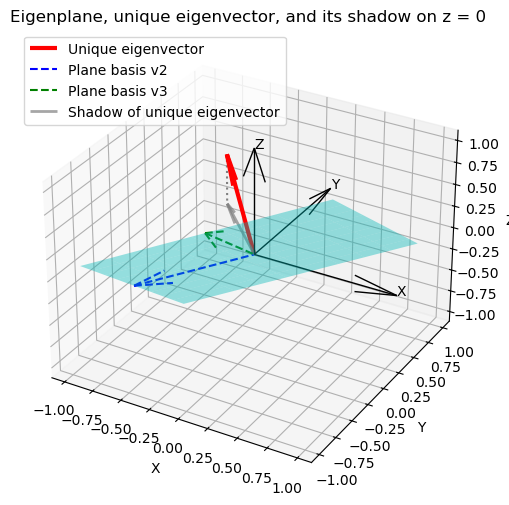

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ---------------------------------------------------------
# Your eigenvectors (columns = eigenvectors)
# ---------------------------------------------------------
eigenvectors = np.array([
    [ -5.7694e-01,  -8.1678e-01, 4.4404e-06],
    [ 5.7755e-01, -4.0796e-01, -7.0710e-01],
    [ 5.7755e-01, -4.0796e-01,  7.0711e-01],
])

# Unique eigenvector (simple eigenvalue)
v_unique = eigenvectors[:, 0]

# Two eigenvectors spanning the degenerate eigenspace (plane)
b1 = eigenvectors[:, 1]
b2 = eigenvectors[:, 2]

# Normalize for visualization
v_unique = v_unique / np.linalg.norm(v_unique)
b1 = b1 / np.linalg.norm(b1)
b2 = b2 / np.linalg.norm(b2)

# ---------------------------------------------------------
# Create grid for the plane span{b1, b2}
# ---------------------------------------------------------
u_vals = np.linspace(-1, 1, 10)
v_vals = np.linspace(-1, 1, 10)
U, V = np.meshgrid(u_vals, v_vals)

X = U * b1[0] + V * b2[0]
Y = U * b1[1] + V * b2[1]
Z = U * b1[2] + V * b2[2]

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# --- Plot the plane ---
ax.plot_surface(X, Y, Z, alpha=0.4, color='cyan')

# --- Plot the unique eigenvector ---
ax.quiver(
    0, 0, 0,
    v_unique[0], v_unique[1], v_unique[2],
    color='red', linewidth=3, label='Unique eigenvector'
)

# --- Plot the two basis eigenvectors of the plane ---
ax.quiver(0, 0, 0, b1[0], b1[1], b1[2],
          color='blue', linestyle='dashed', label='Plane basis v2')
ax.quiver(0, 0, 0, b2[0], b2[1], b2[2],
          color='green', linestyle='dashed', label='Plane basis v3')

# ---------------------------------------------------------
# Shadow of the unique eigenvector on the "floor" (z = 0)
# ---------------------------------------------------------
shadow_end = np.array([v_unique[0], v_unique[1], 0.0])

# Shadow arrow
ax.quiver(
    0, 0, 0,
    shadow_end[0], shadow_end[1], shadow_end[2],
    color='gray', linewidth=2, alpha=0.7, label='Shadow of unique eigenvector'
)

# Vertical line from tip of vector down to its shadow
ax.plot(
    [v_unique[0], shadow_end[0]],
    [v_unique[1], shadow_end[1]],
    [v_unique[2], shadow_end[2]],
    color='gray', linestyle='dotted'
)

# ---------------------------------------------------------
# Coordinate axes
# ---------------------------------------------------------
axis_len = 1.2
ax.quiver(0, 0, 0, axis_len, 0, 0, color='black', linewidth=1)
ax.quiver(0, 0, 0, 0, axis_len, 0, color='black', linewidth=1)
ax.quiver(0, 0, 0, 0, 0, axis_len, color='black', linewidth=1)
ax.text(axis_len, 0, 0, "X", color='black')
ax.text(0, axis_len, 0, "Y", color='black')
ax.text(0, 0, axis_len, "Z", color='black')

# ---------------------------------------------------------
# Set plot limits and labels
# ---------------------------------------------------------
max_range = np.array([
    X.max() - X.min(),
    Y.max() - Y.min(),
    Z.max() - Z.min()
]).max()

mid_x = (X.max() + X.min()) / 2
mid_y = (Y.max() + Y.min()) / 2
mid_z = (Z.max() + Z.min()) / 2

ax.set_xlim(mid_x - max_range/2, mid_x + max_range/2)
ax.set_ylim(mid_y - max_range/2, mid_y + max_range/2)
ax.set_zlim(mid_z - max_range/2, mid_z + max_range/2)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Eigenplane, unique eigenvector, and its shadow on z = 0")

ax.legend(loc="upper left")
plt.show()

